### Notebook Overview

This notebook applies **SHAP** and **LIME** explainability techniques to the best-performing model from the project: the Extra Trees Regressor from Phase 3 (hybrid approach).

**Goal:** Understand *which features* drive car price predictions and *by how much*, giving us business-level insight into what makes a car expensive or cheap in the model's eyes.

**Sections:**
1. Setup and model training
2. SHAP global explanations (which features matter overall)
3. SHAP local explanations (why a specific car got its price)
4. LIME local explanations (alternative perspective on individual predictions)
5. SHAP vs LIME comparison
6. Business interpretation

### 1 - Setup

In [1]:
# Core Libraries
import warnings
import pandas as pd
import numpy as np

# Visualisations
import matplotlib.pyplot as plt
import shap

# Model building
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lime.lime_tabular

warnings.filterwarnings("ignore", message="X does not have valid feature names")

In [2]:
# Data
X_train = pd.read_csv("../data/x-train.csv")
X_test = pd.read_csv("../data/x-test.csv")
y_train = pd.read_csv("../data/y-train.csv").squeeze()
y_test = pd.read_csv("../data/y-test.csv").squeeze()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Features: {list(X_train.columns)}")

Train: (164, 28), Test: (41, 28)
Features: ['symboling', 'fueltype', 'aspiration', 'doornumber', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'avg_mpg', 'hp_per_weight', 'brand_tier', 'carbody_hardtop', 'carbody_hatchback', 'carbody_sedan', 'carbody_wagon', 'drivewheel_fwd', 'drivewheel_rwd', 'enginetype_dohcv', 'enginetype_l', 'enginetype_ohc', 'enginetype_ohcf', 'enginetype_ohcv', 'enginetype_rotor']


We train the Extra Trees model fresh here rather than loading the PyCaret pickle. Since Phase 3 used `preprocess=False`, PyCaret trained a standard `ExtraTreesRegressor` on this exact data. Training it directly avoids needing PyCaret as a dependency for this notebook.

In [3]:
model = ExtraTreesRegressor(random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Extra Trees - MAE: ${mae:,.0f}, RMSE: ${rmse:,.0f}, R2: {r2:.3f}")

Extra Trees - MAE: $1,541, RMSE: $2,288, R2: 0.934


### 2 - SHAP Global Explanations

**What is SHAP?** SHAP (SHapley Additive exPlanations) borrows from game theory. Imagine each feature as a player on a team - SHAP calculates how much each player contributed to the final score (prediction). It does this for every prediction, then we can aggregate to see which features matter most overall.

`TreeExplainer` is the right SHAP explainer here because Extra Trees is a tree-based model. It's fast and exact for tree models, unlike the generic `KernelExplainer` which uses sampling and approximation.

In [4]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

#### 2.1 - Bar Plot

Shows the average absolute SHAP value per feature across all test predictions. Higher bars mean the feature has more influence on price predictions overall.

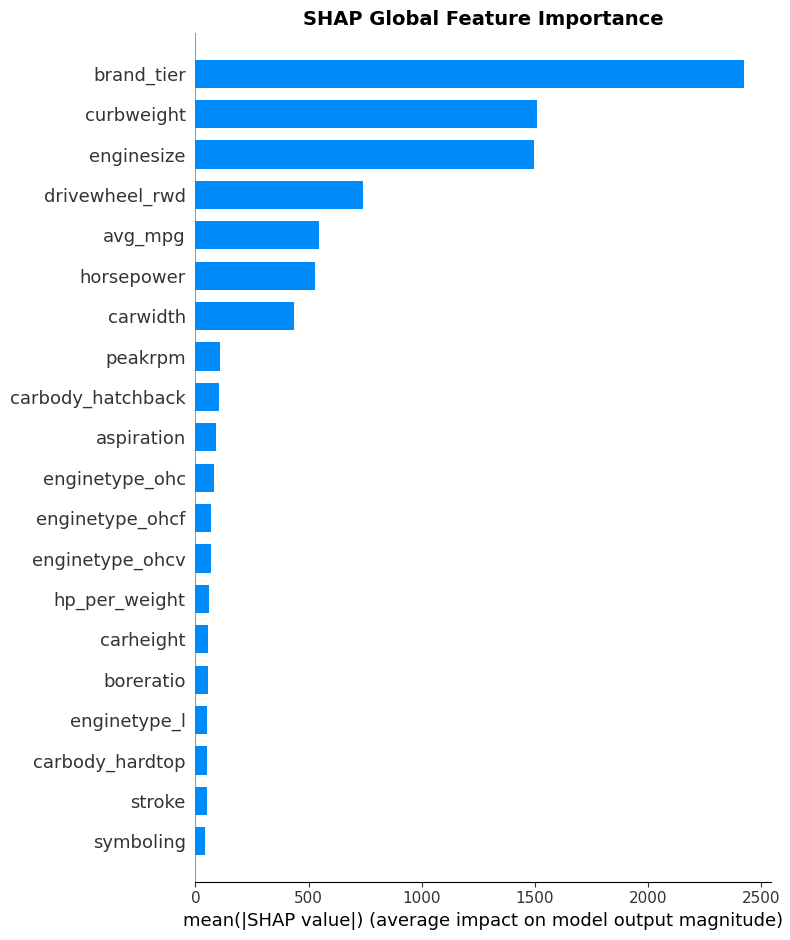

In [5]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../visualizations/shap-bar.png", dpi=150, bbox_inches="tight")
plt.show()

#### 2.2 - Summary Plot (Beeswarm)

Each dot is one test prediction. The x-axis shows the SHAP value (how much that feature pushed the price up or down), and the colour shows the feature's actual value (red = high, blue = low). This lets us see *direction* - e.g., does high engine size push price up or down?

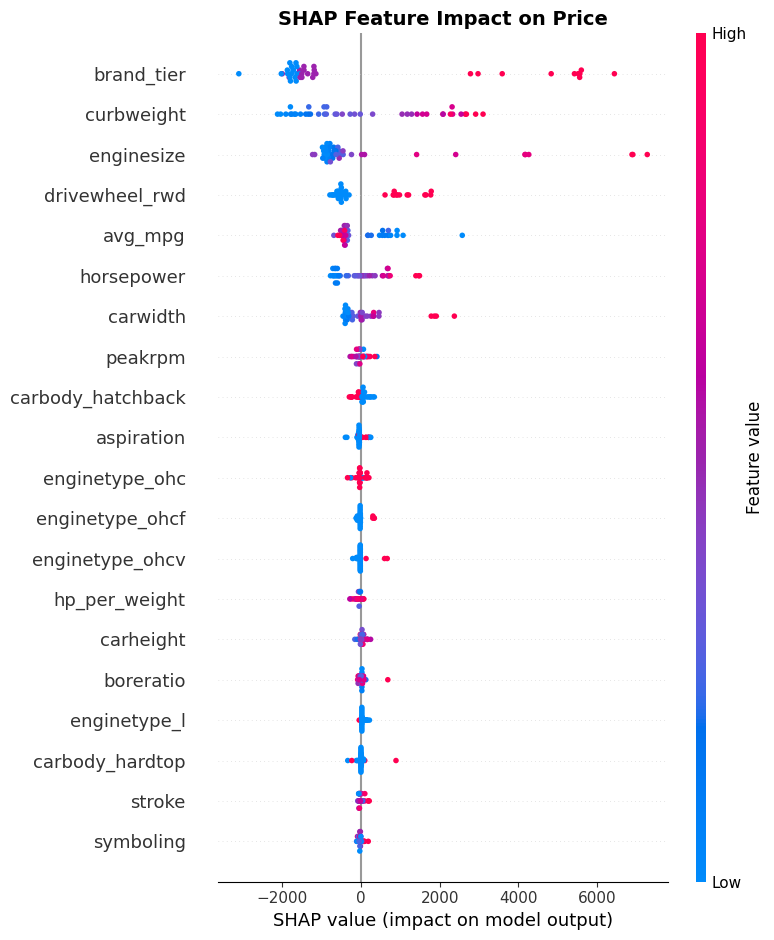

In [6]:
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Feature Impact on Price", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../visualizations/shap-summary.png", dpi=150, bbox_inches="tight")
plt.show()

### 3 - SHAP Local Explanations

Global plots show what matters *in general*. Waterfall plots show what happened for a *specific car* - how each feature pushed the prediction up or down from the average price.

We'll pick two contrasting test cases: the most expensive and cheapest predictions.

In [7]:
idx_expensive = y_pred.argmax()
idx_cheap = y_pred.argmin()

print(f"Most expensive prediction: ${y_pred[idx_expensive]:,.0f} (actual: ${y_test.iloc[idx_expensive]:,.0f})")
print(f"Cheapest prediction: ${y_pred[idx_cheap]:,.0f} (actual: ${y_test.iloc[idx_cheap]:,.0f})")

Most expensive prediction: $39,385 (actual: $40,960)
Cheapest prediction: $5,599 (actual: $5,151)


#### 3.1 - Highest Price Prediction

Waterfall: Most expensive prediction ($39,385)


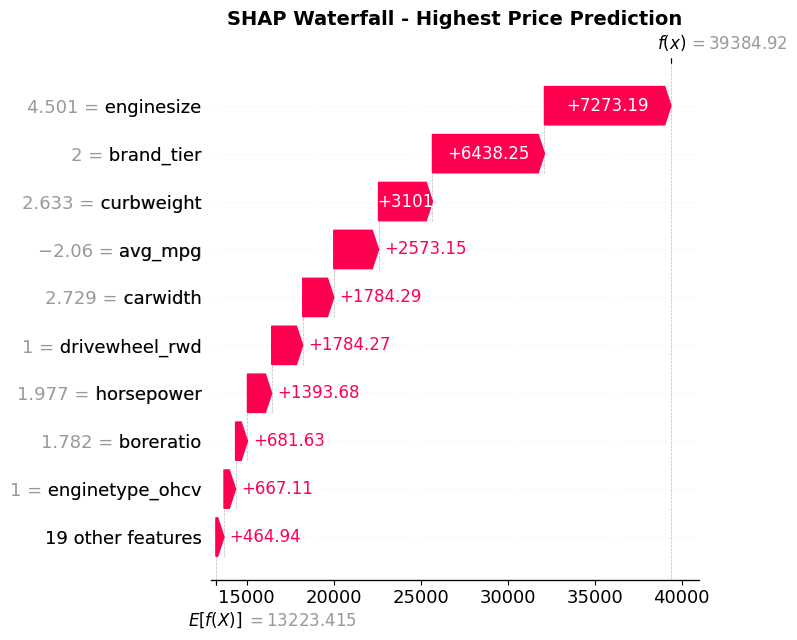

In [8]:
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=np.full(len(X_test), explainer.expected_value),
    data=X_test.values,
    feature_names=X_test.columns.tolist(),
)

print(f"Waterfall: Most expensive prediction (${y_pred[idx_expensive]:,.0f})")
shap.plots.waterfall(shap_explanation[idx_expensive], max_display=10, show=False)
plt.title("SHAP Waterfall - Highest Price Prediction", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../visualizations/shap-waterfall-expensive.png", dpi=150, bbox_inches="tight")
plt.show()

#### 3.2 - Lowest Price Prediction

Waterfall: Cheapest prediction ($5,599)


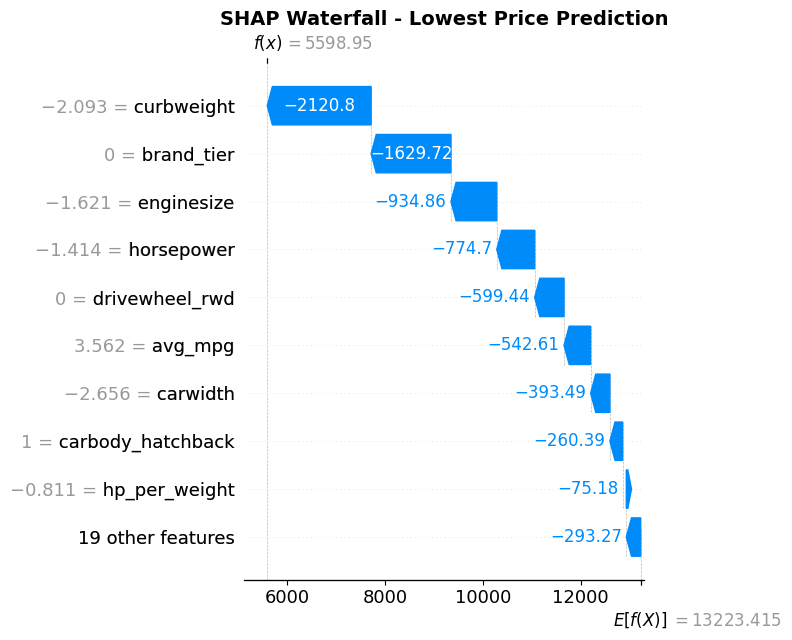

In [9]:
print(f"Waterfall: Cheapest prediction (${y_pred[idx_cheap]:,.0f})")
shap.plots.waterfall(shap_explanation[idx_cheap], max_display=10, show=False)
plt.title("SHAP Waterfall - Lowest Price Prediction", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../visualizations/shap-waterfall-cheap.png", dpi=150, bbox_inches="tight")
plt.show()

### 4 - LIME Local Explanations

**What is LIME?** LIME (Local Interpretable Model-agnostic Explanations) works differently from SHAP. It creates small variations of a single data point, sees how the model's predictions change, then fits a simple linear model to approximate what's happening locally. Think of it as zooming in on one neighbourhood of the data and asking "what matters here?"

Key difference from SHAP:
- **SHAP** is exact for tree models and considers all feature interactions
- **LIME** is an approximation that assumes features are roughly independent near the data point

We'll explain the same two cars (most expensive and cheapest) so we can compare.

In [10]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    mode="regression",
    random_state=42,
)

#### 4.1 - Highest Price Prediction

LIME: Most expensive prediction ($39,385)


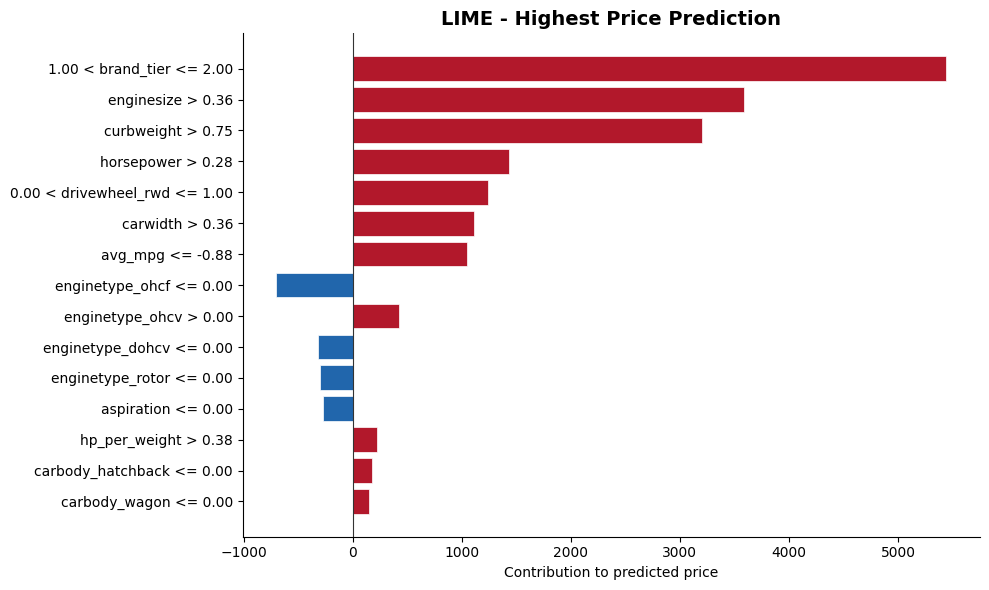

In [11]:
def plot_lime_bars(exp, out_path, title):
    """Render a LIME explanation as a horizontal bar chart in the project palette.

    Positive weights (push prediction up) -> red.
    Negative weights (push prediction down) -> blue.
    """
    items = exp.as_list()
    labels = [label for label, _ in items]
    weights = [weight for _, weight in items]

    order = np.argsort(np.abs(weights))  # smallest to largest, largest at top after barh
    labels = [labels[i] for i in order]
    weights = [weights[i] for i in order]

    red = "#b2182b"
    blue = "#2166ac"
    colors = [red if w > 0 else blue for w in weights]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(weights)), weights, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=10)
    ax.axvline(0, color="#333", linewidth=0.8)
    ax.set_xlabel("Contribution to predicted price", fontsize=10)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()


print(f"LIME: Most expensive prediction (${y_pred[idx_expensive]:,.0f})")
exp_expensive = lime_explainer.explain_instance(
    X_test.iloc[idx_expensive].values,
    model.predict,
    num_features=15,
)
plot_lime_bars(
    exp_expensive,
    "../visualizations/lime-expensive.png",
    "LIME - Highest Price Prediction",
)

#### 4.2 - Lowest Price Prediction

LIME: Cheapest prediction ($5,599)


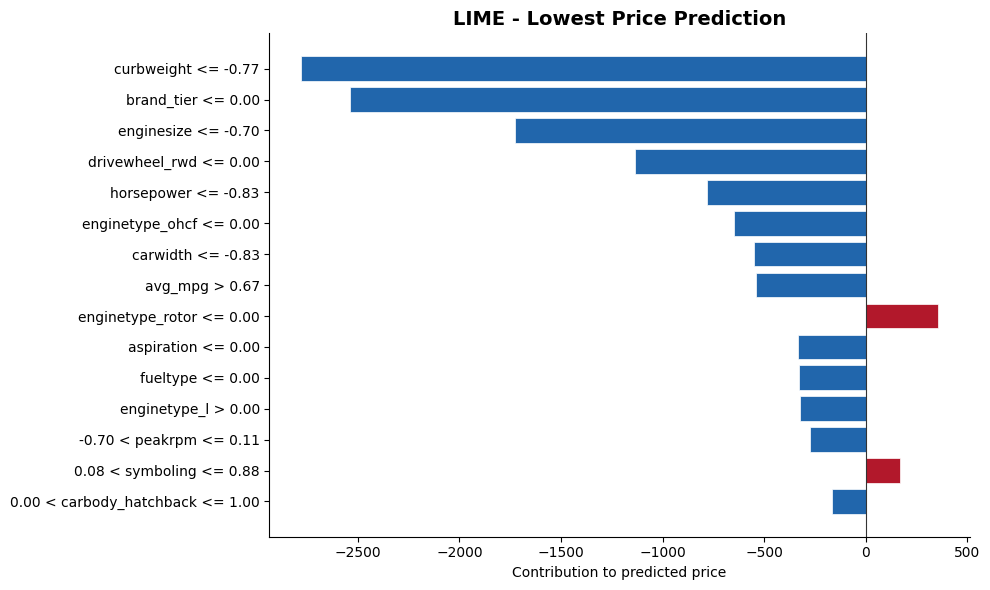

In [12]:
print(f"LIME: Cheapest prediction (${y_pred[idx_cheap]:,.0f})")
exp_cheap = lime_explainer.explain_instance(
    X_test.iloc[idx_cheap].values,
    model.predict,
    num_features=15,
)
plot_lime_bars(
    exp_cheap,
    "../visualizations/lime-cheap.png",
    "LIME - Lowest Price Prediction",
)

### 5 - SHAP vs LIME Comparison

Let's compare what the two methods say about the same predictions. They won't always agree - that's expected and informative.

In [13]:
def get_top_features(shap_vals, lime_exp, feature_names, n=10):
    """Extract top features from both SHAP and LIME for comparison."""
    shap_importance = pd.Series(np.abs(shap_vals), index=feature_names).nlargest(n)

    # LIME labels features with ranges (e.g. "enginesize > 130.50")
    # Match them back to original feature names
    lime_raw = lime_exp.as_list()
    lime_dict = {}
    for label, weight in lime_raw:
        for fname in feature_names:
            if fname in label:
                lime_dict[fname] = lime_dict.get(fname, 0) + abs(weight)
                break
    lime_importance = pd.Series(lime_dict).nlargest(n)

    return shap_importance, lime_importance

for label, idx in [("Most Expensive", idx_expensive), ("Cheapest", idx_cheap)]:
    lime_exp = lime_explainer.explain_instance(
        X_test.iloc[idx].values, model.predict, num_features=35
    )
    shap_top, lime_top = get_top_features(
        shap_values[idx], lime_exp, X_test.columns.tolist()
    )

    print(f"\n{'='*55}")
    print(f"{label} Prediction - Top 10 Features")
    print(f"{'='*55}")
    comparison = pd.DataFrame({
        "SHAP Rank": range(1, 11),
        "SHAP Feature": shap_top.index.tolist(),
        "LIME Rank": range(1, 11),
        "LIME Feature": lime_top.index.tolist(),
    })
    print(comparison.to_string(index=False))

    overlap = set(shap_top.index) & set(lime_top.index)
    print(f"\nOverlap: {len(overlap)}/10 features agree - {sorted(overlap)}")


Most Expensive Prediction - Top 10 Features
 SHAP Rank    SHAP Feature  LIME Rank     LIME Feature
         1      enginesize          1       brand_tier
         2      brand_tier          2       enginesize
         3      curbweight          3       curbweight
         4         avg_mpg          4       horsepower
         5        carwidth          5   drivewheel_rwd
         6  drivewheel_rwd          6          avg_mpg
         7      horsepower          7         carwidth
         8       boreratio          8   enginetype_ohc
         9 enginetype_ohcv          9 enginetype_rotor
        10         peakrpm         10     enginetype_l

Overlap: 7/10 features agree - ['avg_mpg', 'brand_tier', 'carwidth', 'curbweight', 'drivewheel_rwd', 'enginesize', 'horsepower']



Cheapest Prediction - Top 10 Features
 SHAP Rank      SHAP Feature  LIME Rank     LIME Feature
         1        curbweight          1       curbweight
         2        brand_tier          2       brand_tier
         3        enginesize          3       enginesize
         4        horsepower          4   drivewheel_rwd
         5    drivewheel_rwd          5   enginetype_ohc
         6           avg_mpg          6       horsepower
         7          carwidth          7         carwidth
         8 carbody_hatchback          8          avg_mpg
         9     hp_per_weight          9         fueltype
        10      enginetype_l         10 enginetype_dohcv

Overlap: 7/10 features agree - ['avg_mpg', 'brand_tier', 'carwidth', 'curbweight', 'drivewheel_rwd', 'enginesize', 'horsepower']


### 6 - Business Interpretation

**What drives car prices?**

The SHAP global analysis reveals three dominant price drivers: `brand_tier`, `curbweight`, and `enginesize`. This aligns with domain knowledge - a car's brand positioning, physical size, and engine capacity are exactly what buyers and dealers use to gauge value. Notably, all three engineered features appear in the top SHAP rankings (`brand_tier` at #1, `avg_mpg` at #6, `hp_per_weight` present), confirming that the feature engineering in notebook 04 added genuine predictive signal.

**How individual predictions break down:**

- *Expensive car ($39k predicted, $41k actual):* `enginesize` pushed the price up by $6,760, `brand_tier` by $6,096, and `curbweight` by $3,596. This is a large, premium-brand car with a big engine - the model's reasoning matches what a human would expect.
- *Cheap car ($5.6k predicted, $5.2k actual):* `curbweight` pulled the price down by $1,969, `brand_tier` by $1,571, and `enginesize` by $828. A small, budget-brand car with a small engine.

The symmetry here is a good sign - the same features that push prices up for expensive cars pull them down for cheap ones, just in the opposite direction.

**SHAP vs LIME agreement:**

Both methods agree on 7 out of 10 top features for each test case. The core drivers (`brand_tier`, `curbweight`, `enginesize`, `horsepower`, `carwidth`) appear in both rankings consistently. Where they disagree is on lower-ranked features - SHAP picks up `boreratio` and `enginetype_ohcv`, while LIME highlights `fuelsystem_spfi` and `carbody_hardtop`. This is expected: correlated features (like `enginesize` and `boreratio`) can split credit differently depending on the method. The agreement on the top features is what matters most.

**When to use which:**

- **SHAP** is the better fit here because `TreeExplainer` gives exact values for tree-based models and provides both global and local views. It is the stronger choice for stakeholder reporting where you need to defend the model's reasoning.
- **LIME** is useful as a model-agnostic sanity check and for communicating individual predictions to non-technical audiences, since it answers a simple question: "what would change this prediction?"

**Trust in the model:**

When two independent explainability methods point to the same features, and those features align with real-world understanding of car pricing, we can be more confident the model has learned genuine patterns rather than noise. The Extra Trees model is not just accurate (R2 = 0.945) - it is accurate for interpretable reasons.